# Débruitage de Vuvuzela

# Turpin Antoine et Le Poulichet Alexandre

In [ ]:
from numpy import *
from matplotlib.pyplot import *
import scipy.signal as signal
from scipy.io import wavfile
from IPython import *


## Introduction

### Contexte / Problématique

Lors de la coupe du Monde de Football 2010, les téléspectateurs du monde entier ont pu découvrir un instrument de musique d’Afrique du Sud : le Vuvuzela. Passé la phase d’étonnement, le son continu généré par cet instrument est rapidement devenu gênant lors de la diffusion des matchs ([youtube](https://www.youtube.com/watch?v=bKCIFXqhLzo)). Dans ce projet, nous allons mettre en place un filtre "anti-vuvuzela" pour atténuer les sonorités de cet instrument.

<figure style="padding:40px;align:center">
<img style="width: 400px" src="https://i.dailymail.co.uk/i/pix/2010/06/13/article-1286265-09FE0925000005DC-48_468x299.jpg">
</figure>

### Méthodologie

In [ ]:
Fs,data = wavfile.read("wav/vuvuzela.wav")     #read wavefile
data = data/(1.1*max(abs(data)))               # normalisation
#Audio(data,rate=Fs)

NameError: name 'wavfile' is not defined

Le repo gitlab contient un enregistrement sonore nommé `vuvuzela.wav` dans le repertoire `wav`. Cet enregistrement a été réalisé lors d’un match de la coupe du monde 2010. Pour supprimer les sonorités de Vuvuzela, nous allons procéder de la manière suivante :

1. Analyse du contenu spectral du fichier `vuvuzela.wav`. Identification des fréquences à rejeter.
2. Analyse et étude expérimentale de différents "rejecteurs" :`
    * un filtre RLC,
    * un filtre Twin T passif,
    * un filtre Twin T actif.
3. Simulation avec python et LTSpice de la structure sélectionnée. Mise en cascade des filtres.
4. Câblage de la cascade et test de l’ensemble sur le signal audio fourni.

Pour chacune de ces étapes, les analyses et résultats expérimentaux devront apparaître dans le notebook Jupyter en expliquant et justifiant votre démarche.

## Analyse Spectrale


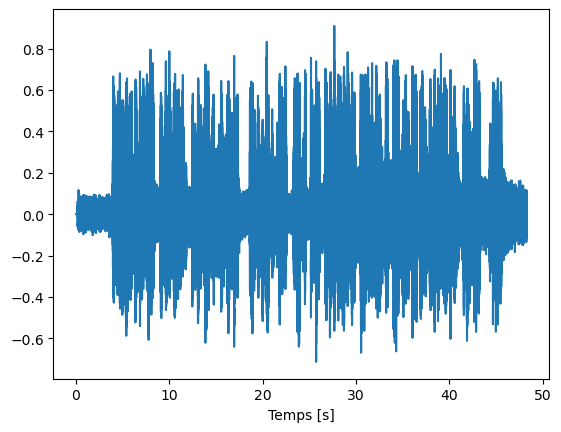

In [ ]:
t = arange(len(data))/Fs         #convert sample index to time (in sec)
plot(t,data)
xlabel("Temps [s]");

La figure précédente affiche la représentation temporelle de l'enregistrement sonore à débruiter. Cet enregistrement contient des parties contenant uniquement les sonorités de Vuvuzela (entre 0 et 2s par exemple) et d'autres parties contenant les sonorités de Vuvuzela ainsi que des commentaires de journalistes sportifs.
Mathématiquement, les sonorités de Vuvuzela peuvent être modélisés par une somme de plusieurs sinusoïdes de fréquence $f_l$ c-a-d

$$x(t) = \sum_{l=1}^L a_l sin(2\pi f_l l t + \varphi_l)$$

Dans un premier temps, il est nécessaire de déterminer les fréquences $f_1$,$\cdots$, $f_L$ en réalisant une analyse spectrale (c-a-d fréquentielle) de l’enregistrement sonore. L'analyse pourra être réalisée en utilisant Python. Ccette partie nécessitera d’utiliser la fonctionnalité suivante :

* Estimation du spectre: [Documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html)

En utilisant `python`, représentez le contenu temporel puis fréquentiel de l'enregistrement sonore.

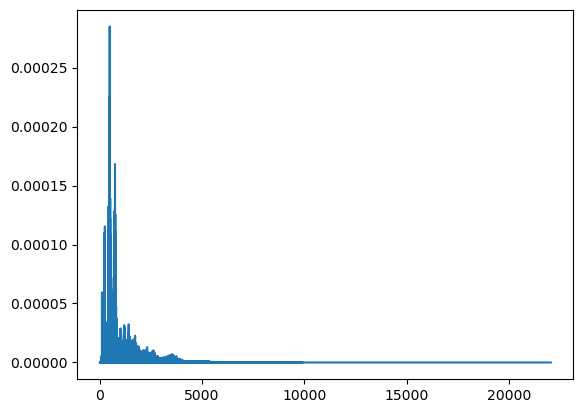

In [ ]:
%matplotlib inline
f,Pxx=signal.periodogram(data,Fs)
plot(f,Pxx)

Isolez une portion temporelle de l’enregistrement sonore ne contenant que des sonorités de Vuvuzela (pas de commentaires sportifs). Représentez alors le contenu fréquentiel de cette portion.



154350.0


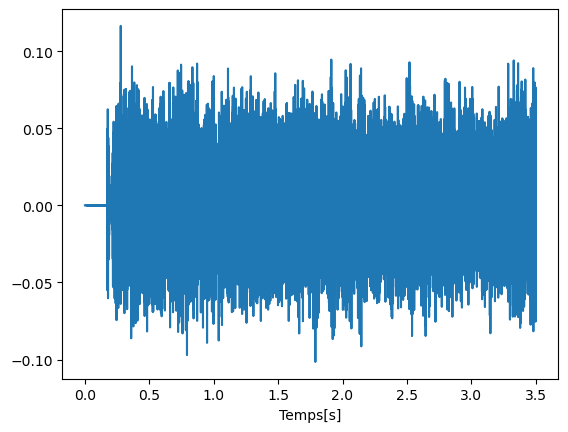

In [ ]:
%matplotlib inline
n=Fs*3.5
print(n)
wavfile.write("vuvuzela_only.wav", Fs,data[0:int(Fs*3.5)])
Fs,data_v=wavfile.read("vuvuzela_only.wav")
t = arange(len(data_v))/Fs
plot(t,data_v)
xlabel("Temps[s]");

Identifiez les composantes fréquentielles du son de Vuvuzela c-a-d les valeurs de $f_l$ ($k = 1,\cdots,L$). Retrouvez alors l'unique note de la gamme tempérée qu'est capable de générer le Vuvuzela.

le max est 234.0


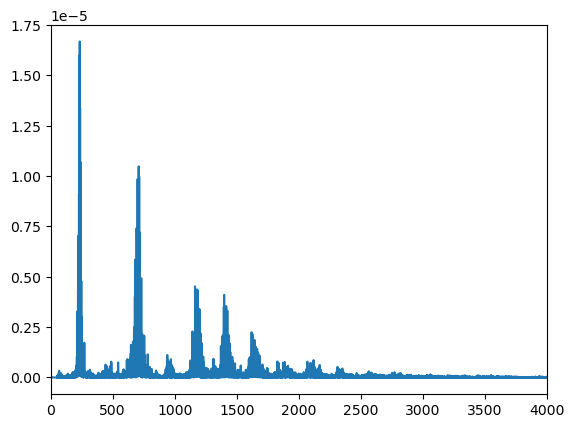

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
f,Pxx=signal.periodogram(data_v,int(Fs))
plot(f,Pxx)
plt.xlim(0.0,4000)
indice_max=np.argmax(Pxx)
max_x=f[indice_max]
print(f"le max est {max_x}")

# Filtre rejecteur RLC





Dans un premier temps, nous allons considérer le rejecteur RLC suivant :

<figure style="padding:40px;align:center">
<img style="width: 250px" src="./img/RLC.png">
<figcaption style='text-align:center;padding-top:20px;font-style: italic;'>Fig. Filtre RLC</figcaption>
</figure>

## On pose :

$$ Z_r = R \quad \text{et} \quad Z_2 = jL\omega + \frac{1}{jC\omega} = \frac{j^2L\omega C^2 + 1}{jC\omega} $$

## Par pont diviseur de tension :

$$ T(j\omega) = \frac{Z_2}{Z_r + Z_2} = \frac{\frac{j^2L\omega C^2 + 1}{jC\omega}}{\frac{j^2L\omega C^2 + 1}{jC\omega} + R} $$

## Au final :

$$ T(j\omega) = \frac{Lc(j\omega)^2 + 1}{Lc(j\omega)^2 + 1 + Rcj\omega} $$
$$ $$
## Par identification avec la forme normalisée du notch on a :

$$ T_m = 1 \quad \text{et} \quad \omega_0 = \frac{1}{\sqrt{LC}} \quad \text{et} \quad m = \frac{RC}{2\sqrt{LC}} \quad \text{et} \quad f_0 = \frac{\omega_0}{2\pi}
$$

On cherche maintenant à déterminer l’expression de la largeur de la bande rejetée à −3dB.

Largeur de la bande rejetée à -3dB:
\begin{align}
Δw = 2mwo=\frac{R}{L}
\end{align}
$$ $$
*   $$ T_m : \text{amplification maximale} $$
*   $$ \text{m : amortissement} $$
*   $$ w_0 : \text{pulsation propre} $$
*   $$ f_0 : \text{fréquence propre} $$



## Dimensionnement des composants

## Afin de facilité le dimensionnement des composants nous avons décidé de fixer R = 1000 ohms
## Choix de l'amortissement m :
Dans le cadre de notre projet, nous avons opté pour m= 0.25 pour plusieurs raisons. Tout d'abord, ce choix nous permet d'éviter de trop atténuer la fréquence du signal garantissant ainsi une réponse en fréquence stable et uniforme. Avec un choix d'un amortissement assez petit on est garantit d'obtenir un signal de qualité avec un son bien audible. Enfin, on arrive quand même a bien atténuer les fréquences que l'on souhaitent atténuer avec ce choix.

In [ ]:
import math

def get_components(f0, m):
    R = 1000
    w0 = 2 * math.pi * f0
    C = (2 * m) / (w0 * R)
    L = ((1 / w0) ** 2) / C
    return {"R": R, "L": L, "C": C}

# Liste des valeurs de f0 à attenuer
f0_liste = [234, 710, 1164, 1400, 1620]

m = 0.25

# Calculer les composants L et C pour chaque valeur de f0
for f0 in f0_liste:
    components = get_components(f0, m)
    print(f"f0 = {f0} Hz, R = {components['R']} ohms, L = {components['L']} H, C = {components['C']} F")


f0 = 234 Hz, R = 1000 ohms, L = 0.20363752378818686 H, C = 2.2716987603714976e-06 F
f0 = 710 Hz, R = 1000 ohms, L = 0.06711433882596582 H, C = 7.487007182069443e-07 F
f0 = 1164 Hz, R = 1000 ohms, L = 0.040937440349171586 H, C = 4.566817095592186e-07 F
f0 = 1400 Hz, R = 1000 ohms, L = 0.0340365575474541 H, C = 3.7969822137637893e-07 F
f0 = 1620 Hz, R = 1000 ohms, L = 0.029414308991626996 H, C = 3.2813426538699413e-07 F


### Diagrammes de Bode

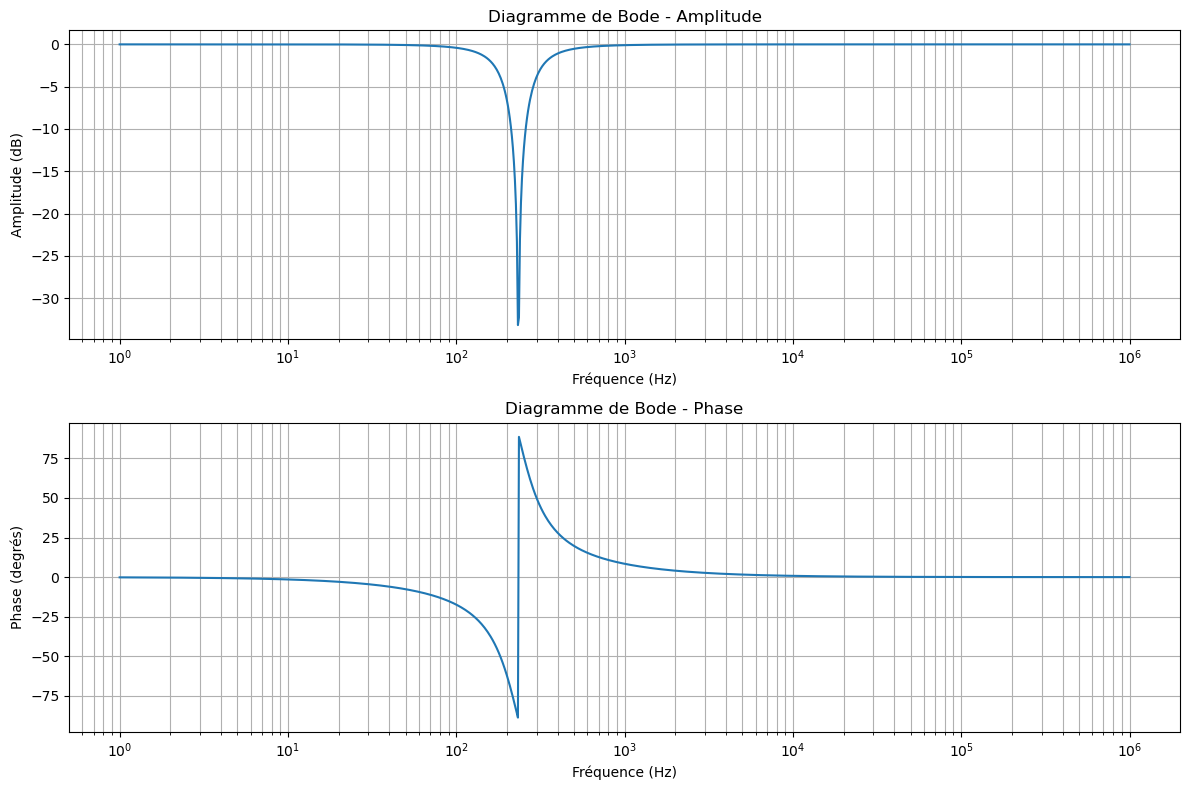

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du filtre
f_0 = 234  # Fréquence propre en Hz
m = 0.25  # Amortissement

# Calcul de la pulsation propre
omega_0 = 2 * np.pi * f_0  # Pulsation propre en rad/s

# Définir la fonction de transfert en termes de ω, ω₀ et m
def H(jw, omega_0, m):
    s = jw / omega_0
    num = s**2 + 1
    den = s**2 + s/m + 1
    return num / den

# Définir la plage de fréquences
frequencies = np.logspace(0, 6, 1000)  # De 1 Hz à 1 MHz
omega = 2 * np.pi * frequencies
jw = 1j * omega

# Calculer la réponse en fréquence
H_jw = H(jw, omega_0, m)

# Amplitude (en dB) et phase (en degrés)
amplitude_dB = 20 * np.log10(np.abs(H_jw))
phase_deg = np.angle(H_jw, deg=True)

# Tracer les diagrammes de Bode
plt.figure(figsize=(12, 8))

# Diagramme de Bode - Amplitude
plt.subplot(2, 1, 1)
plt.semilogx(frequencies, amplitude_dB)
plt.title('Diagramme de Bode - Amplitude')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude (dB)')
plt.grid(which='both', axis='both')


# Diagramme de Bode - Phase
plt.subplot(2, 1, 2)
plt.semilogx(frequencies, phase_deg)
plt.title('Diagramme de Bode - Phase')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (degrés)')
plt.grid(which='both', axis='both')

plt.tight_layout()
plt.show()


## Critique et conclusion du filtre :

L'utilisation de bobines dans les circuits RLC peut poser des problèmes en raison de leur résistance interne, ce qui peut affecter de manière significative les performances du circuit (pertes d'énergie et réduction de la précision). En effet, leur performance dépend fortement de la qualité des composants, de la précision des valeurs choisies, de la stabilité dans le temps, et de l'interaction avec le circuit environnant.

# Filtre rejecteur Twin-T





Pour éviter d’utiliser plusieurs bobines, nous allons maintenant considérer un filtre rejecteur Twin-T passif. Ce filtre est décrit dans la figure suivante :

<figure style="padding:40px;align:center">
<img style="width: 250px" src="./img/twinT.png">
<figcaption style='text-align:center;padding-top:20px;font-style: italic;'>Fig. Filtre Twin-T</figcaption>
</figure>

## Fonction de transfert associé au rejecteur Twin-T passif :
$$ $$ \begin{align}
T(p) & = \frac{{{(RCp)^2}+1}}{{(RCp)}^2 + {4RC}p+ 1}
\end{align}

$$ $$
## Expression du coefficient d'amortissement m : \begin{align}
m & = {{1.5}}
\end{align}


$$ $$
## Expression de la pulsation de cassure\begin{align}
w_0 & = \frac{{1}}{{RC}}
\end{align}
$$ $$
## la valeur de f est donc :

\begin{align}
f  =\frac{1}{2πRC}
\end{align}
<br>

## On cherche maintenant à déterminer l’expression de la largeur de la bande rejetée à −3dB. On sait que :

\begin{align}
Δw  = 2mw_0
\end{align}

## Ce qui est égal à :     

\begin{align}
Δw  = \frac{4}{RC}
\end{align}



## Dimensionnement des composants

In [ ]:
import math

def calculate_components(frequency, m=2):
    R = 1000  # Résistance en ohms
    w0 = 2 * math.pi * frequency  # Pulsation angulaire
    C = 1 / (w0 * R)  # Capacité en farads
    return {"R": R, "C": C}

# Fréquences pour lesquelles générer les composants
frequencies = [234, 710, 1164, 1400, 1620]

# Génération et affichage des composants pour chaque fréquence
for frequency in frequencies:
    components = calculate_components(frequency)
    print(f"Fréquence: {frequency} Hz, Composants: {components}")

Fréquence: 234 Hz, Composants: {'R': 1000, 'C': 6.801493294525441e-07}
Fréquence: 710 Hz, Composants: {'R': 1000, 'C': 2.2416189167872585e-07}
Fréquence: 1164 Hz, Composants: {'R': 1000, 'C': 1.3673105076623313e-07}
Fréquence: 1400 Hz, Composants: {'R': 1000, 'C': 1.1368210220849668e-07}
Fréquence: 1620 Hz, Composants: {'R': 1000, 'C': 9.824379203203417e-08}


## Diagrammes de Bode

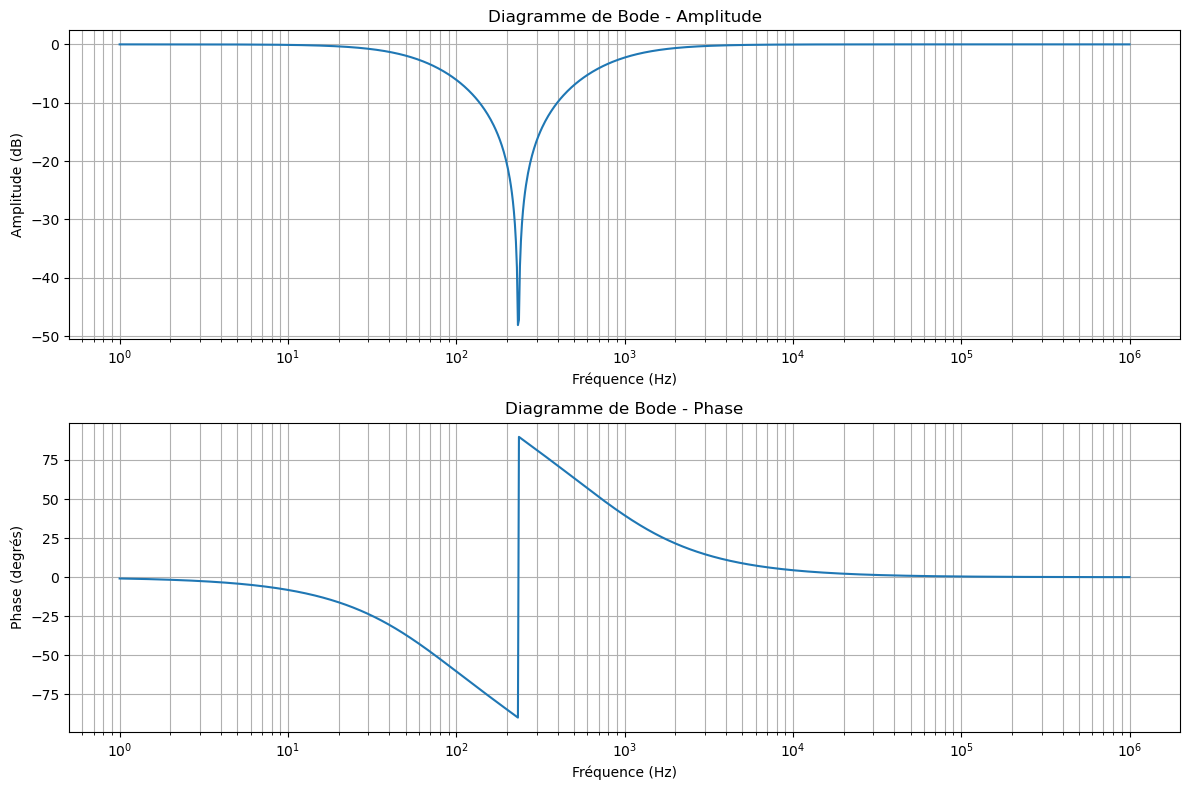

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du filtre
f_0 = 234  # Fréquence propre en Hz
m = 0.25  # Amortissement
Q = 1 / (2 * m)  # Facteur de qualité

# Calcul de la pulsation propre
omega_0 = 2 * np.pi * f_0  # Pulsation propre en rad/s

# Définir la fonction de transfert en termes de ω, ω₀ et Q
def H(jw, omega_0, Q):
    s = jw / omega_0
    num = s**2 + 1
    den = s**2 + (1/Q) * s + 1
    return num / den

# Définir la plage de fréquences
frequencies = np.logspace(0, 6, 1000)  # De 1 Hz à 1 MHz
omega = 2 * np.pi * frequencies
jw = 1j * omega

# Calculer la réponse en fréquence
H_jw = H(jw, omega_0, Q)

# Amplitude (en dB) et phase (en degrés)
amplitude_dB = 20 * np.log10(np.abs(H_jw))
phase_deg = np.angle(H_jw, deg=True)

# Tracer les diagrammes de Bode
plt.figure(figsize=(12, 8))

# Diagramme de Bode - Amplitude
plt.subplot(2, 1, 1)
plt.semilogx(frequencies, amplitude_dB)
plt.title('Diagramme de Bode - Amplitude')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude (dB)')
plt.grid(which='both', axis='both')

# Diagramme de Bode - Phase
plt.subplot(2, 1, 2)
plt.semilogx(frequencies, phase_deg)
plt.title('Diagramme de Bode - Phase')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (degrés)')
plt.grid(which='both', axis='both')

plt.tight_layout()
plt.show()


## Critique et conclusion du filtre :

# Filtre rejecteur Twin-T actif

Pour obtenir une réponse réjecteur efficace, la valeur de m doit être inférieure à 1. Cependant, dans notre cas, la valeur de m est de 1.67
Avec une valeur de m de 1.67, le résultat devient inaudible car la bande passante du filtre est beaucoup trop large, et la bande de fréquence rejetée affecte une trop grande partie du signal. Il serait donc préférable de choisir un filtre Twin-T actif, car il permet de contrôler le coefficient d’amortissement m. Le filtre Twin-T actif utilise des éléments actifs, tels que des amplificateurs opérationnels, pour obtenir une meilleure précision et une plus grande flexibilité dans le réglage des paramètres du filtre.



Le filtre précédent ne permet pas d'obtenir des résultats sonores satisfaisants. Pour améliorer le résultat sonore, il est possible d'utiliser un filtre Twin-T actif. Contrairement au filtre Twin-T passif, le filtre Twin-T actif permet le contrôle du coefficient d'amortissement $m$. Le tutoriel [MT-225 d’Analog Devices](https://www.analog.com/media/en/training-seminars/tutorials/MT-225.pdf) décrit la structure de ce filtre et donne plusieurs recommandations pour choisir les composants.


## On a
$$ T(p) = \frac{Vs - \ln Vs}{Ve - \ln Vs} $$

$$ Vs(1 - \ln + \ln T(p)) = T(p)Ve $$

$$ T'(p) = \frac{Vs}{Ve} = \frac{T(p)}{1 - \ln + \ln T(p)} $$
$$ $$
## D'après la datasheet fourni sur moodle :     
$$ $$
$$  \frac{Vs}{Ve} = \frac{s^2 + \omega_0^2}{s^2 + \frac{s\omega_0}{Q} + \omega_0^2}  = \frac{s^2 + \left(\frac{1}{RC}\right)^2}{s^2 + s\left(\frac{1}{RC}\right)\left(\frac{4}{1 + \frac{R_5}{R_4}}\right) + \left(\frac{1}{RC}\right)^2} $$

## Ce qui revient à cela : \begin{align}
T(p) & = \frac{{{(RCp)^2}+1}}{{(RCp)}^2 + \frac{4RC}{1+\frac{R5}{R4}}p+ 1}
\end{align}


## Expression du coefficient d'amortissement m : \begin{align}
m & = \frac{2}{1+\frac{R5}{R4}}
\end{align}

## Expression de la pulsation propre ω0 :    

\begin{align}
w_0 & = \frac{{1}}{{RC}}
\end{align}

## On cherche maintenant à déterminer l’expression de la largeur de la bande rejetée à −3dB. On sait que :

\begin{align}
Δw= 2mw_0
\end{align}

## Ce qui est égal à :     

\begin{align}
Δw= \frac{4}{(1+\frac{R5}{R4})RC}
\end{align}

## De plus, la datasheet nous indique que :
$$ $$
$R_1 = R_2 = R$
$$ $$
$R = \frac{1}{{2\pi f_0 C}}$ \
$$ $$
$R_3 = \frac{R}{2}$ et $C_3 = 2C$ \
$$ $$
$C_1 = C_2 = C$ \
$$ $$
$Q = \frac{{1 + \frac{R_5}{R_4}}}{4}$


In [ ]:
import math

# Fonction pour calculer les composants pour une valeur de f0 donnée
def calculer_composants(f0, C1, R5, R4):
    R1 = R2 = R = 1 / (2 * math.pi * f0 * C1 * 10**(-9))
    R3 = R / 2
    C3 = 2 * C1 * 10**(-9)
    Q = (1 + R5 / R4) / 4
    return R1, R2, R3, C3, Q

# Liste des valeurs de f0
f0_liste = [234, 710, 1164, 1400, 1620]

# Valeur de C1 en nF
C1 = 10

# Valeur de R5 et R4 fixées arbitrairement
R5 = 50000
R4 = 7000

# Calculer les composants pour chaque valeur de f0
for f0 in f0_liste:
    R1, R2, R3, C3, Q = calculer_composants(f0, C1, R5, R4)
    m = (1) / (2 * Q)
    print(f"Pour f0 = {f0} Hz : R1 = {R1:.2f} ohms, R2 = {R2:.2f} ohms, R3 = {R3:.2f} ohms, C3 = {C3} F, Q = {Q:.2f}, m = {m:.2f}")


Pour f0 = 234 Hz : R1 = 68014.93 ohms, R2 = 68014.93 ohms, R3 = 34007.47 ohms, C3 = 2e-08 F, Q = 2.04, m = 0.25
Pour f0 = 710 Hz : R1 = 22416.19 ohms, R2 = 22416.19 ohms, R3 = 11208.09 ohms, C3 = 2e-08 F, Q = 2.04, m = 0.25
Pour f0 = 1164 Hz : R1 = 13673.11 ohms, R2 = 13673.11 ohms, R3 = 6836.55 ohms, C3 = 2e-08 F, Q = 2.04, m = 0.25
Pour f0 = 1400 Hz : R1 = 11368.21 ohms, R2 = 11368.21 ohms, R3 = 5684.11 ohms, C3 = 2e-08 F, Q = 2.04, m = 0.25
Pour f0 = 1620 Hz : R1 = 9824.38 ohms, R2 = 9824.38 ohms, R3 = 4912.19 ohms, C3 = 2e-08 F, Q = 2.04, m = 0.25


## Diagrammes de Bode

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du circuit
f_0 = 234  # Fréquence propre en Hz
m = 0.25  # Amortissement

# Calcul de la pulsation propre
omega_0 = 2 * np.pi * f_0  # Pulsation propre en rad/s

# Fonction de transfert du circuit twin-T actif rejetant
def H(jw, omega_0, m):
    s = jw / omega_0
    num = s**2 + omega_0**2
    den = s**2 + s*omega_0/m + omega_0**2
    return num / den

# Définir la plage de fréquences
frequencies = np.logspace(0, 6, 1000)  # De 1 Hz à 1 MHz
omega = 2 * np.pi * frequencies
jw = 1j * omega

# Calculer la réponse en fréquence
H_jw = H(jw, omega_0, m)

# Amplitude (en dB) et phase (en degrés)
amplitude_dB = 20 * np.log10(np.abs(H_jw))
phase_deg = np.angle(H_jw, deg=True)

# Tracer les diagrammes de Bode
plt.figure(figsize=(12, 8))

# Diagramme de Bode - Amplitude
plt.subplot(2, 1, 1)
plt.semilogx(frequencies, amplitude_dB)
plt.title('Diagramme de Bode - Amplitude')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude (dB)')
plt.grid(which='both', axis='both')

# Diagramme de Bode - Phase
plt.subplot(2, 1, 2)
plt.semilogx(frequencies, phase_deg)
plt.title('Diagramme de Bode - Phase')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Phase (degrés)')
plt.grid(which='both', axis='both')

plt.tight_layout()
plt.show()


## Critique et conclusion du filtre :

Ce type de filtre est privilégié en raison de sa bande passante plus étroite, ce qui lui permet de cibler plus précisément les fréquences à supprimer. De plus, il offre une atténuation plus marquée des fréquences rejetées par rapport aux filtres rejetants conventionnels. Les amplificateurs opérationnels (AOP) sont utilisés pour compenser le problème d'atténuation excessive du signal. De plus, ce filtre présente une phase pratiquement nulle en dehors des fréquences à rejeter, ce qui permet de conserver un signal plus clair et audible. Cependant, il peut être limité en termes de fréquence de fonctionnement et de bande passante, ce qui restreint son utilisation dans certaines applications à haute fréquence. De plus, les performances du filtre Twin T actif peuvent être sensibles aux variations des valeurs des composants, entraînant des erreurs de précision et une instabilité dans d'autres contextes.

# Simulation

Après avoir étudié les différents filtres disponibles, nous avons procédé à la mise en cascade de 5 filtres T-Win actif afin d'atteindre notre objectif de retirer les sons parasites. Ceci impliqua par conséquent un bon dimensionnement des composants pour atténuer les fréquences souhaitées. Voici par conséquent la structure générale de note système :


![Schéma du circuit](IMG/circuit.png)
                                            Figure 1 : Schéma complet du câblage final


A présent nous pouvons passer aux résultats obtenus grâce à ce câblage étape par étape en commencant par la sortie  qui permet d'atténuer de la fréquence 234
Hz :

![Schéma du circuit](IMG/circuit_1.png)
Figure 2 : (schéma de la première cascade du twin-T actif

)

![Schéma du circuit](IMG/Vs1_234Hz.png)
Figure 3 : (screenshot de vs1 à 234hz sur ltspice)

Nous pouvons observer ci dessus la différence de tension entre l'entrée V(signal_audio) et la sortie V(sortie1). Nous pouvons observer sur ce graphique qu'au moment ou nous nous approchons de la fréquence souhaité (ici 234 Hz), le signal d'entrée est fortement atténué, et ce sans pour autant avoir un impacte notable sur le reste du signal. Ceci nous permet alors de dire que la fréquence 234 Hz à bien été traité par ce filtre. De ce fait nous pouvons regarder la suite des résultats afin de vérifier la mise en cascade.

Voici ci_dessous les résultats obtenus avec tous les autres Twin Actifs :

Figure 4: Sortie du second circuit (fréquence 710Hz ciblée)
![Schéma du circuit](IMG/Vs2_710Hz.png)Figure 5:
Sortie du 3ème circuit (fréquence 1164Hz ciblée)
![Schéma du circuit](IMG/Vs3_1164Hz.pnFigure 6: g)
Sortie du circuit (fréquence 1400Hz ciblée)
![Schéma du circuit](IMG/Vs4_1400Hz.Figure 7: png)
Sortie du dernier circuit (fréquence 1620Hz ciblée)
![Schéma du circuit](IMG/Vs_1620Hz.png)

Nous pouvons observer sur ces graphiques que chacunes des fréquences ciblées ont bien été atténué, ce qui implique par conséquent que les sons parasites ont bien été traitées. D'autre part voici ci dessous la comparaison des résultats de l'entrée signal_audio et la sortie :


![Schéma du circuit](IMG/Vs_Ve.png)Hz.png)

# Cablage du système

Après avoir obtenu des résultats dans la simulation, nous avons pû passer à la partie câblage. Ceci nous permettant de tester dans de réels condition notre système, en vérifiant grâce au signal de Bode le traitement des bonnes fréquences.

En effet nous allons pouvoir observer notre câblâge ainsi que les résultats de l'ocsilloscope.
Nous avons cablée trois filtres en cascade afin de tester notre système
![Schéma du circuit](IMG/cablage.jpg).png)

En prenant une valeur de fréquence arbitraire qui n'appartient pas aux fréquences que nous souhaitons effacer, nous obtenons ce résultat en sortie.

![Schéma du circuit](IMG/2000.jpg)

Ceci nous montre que le signal est bel et bien atténué légèrement, mais qu'en est-il pour les fréquences parasites ? Et bien voici le résultat à la sortie lorsque nous utilisons 710Hz:

![Schéma du circuit](IMG/Vs2.jpg)

Et les résultats pour 234 Hz:
![Schéma du circuit](IMG/Vs1.jpg)

Nous pouvons remarquer ici que nos deux graphiques ont bel et bien supprimé la présence des fréquences parasites, par conséquent sur l'audio nous devrions entendre le présentateur puisque le vuvuzela à bien été retirer de la bande son.

Suite à des vérifications, nous avons remarqué que à hautes fréquences, le signal de sortie était toujours fortement atténué, par conséquent le résultat final serait bien de trop faible.

Par conséquent nous avons testé une valeur plus faible d'amortissement m, permettant à la fois de supprimer au mieux les bruits parasites et de conserver le plus possible les amplitudes des autres fréquences.
De ce fait voici les résultats que nous avons obtenus avec une valeur m=0.25 :
![Schéma du circuit](IMG/5k_vs.png)
![Schéma du circuit](IMG/2.5k_vs.png)
![Schéma du circuit](IMG/234_vs.png)
![Schéma du circuit](IMG/710_vs.png)

Ces Résultats nous montre bien qu'a des fréquences supérieur à 2KHz nous conservons un signal avec une bonne amplitude, et les fréquences ciblées (ici 234Hz et 710Hz) ont bien été fortement atténués.

Enfin nous avons tracé le diagramme de Bode et nous avons bel et bien obtenu deux fréquences parasites supprimées en sortie (car nous avons eu une erreur sur le troisième circuit). Ce qui nous donne par conséquent ces résultats :
![Schéma du circuit](IMG/Bode_234.png)
![Schéma du circuit](IMG/Bode_706.png)

Nous pouvons par conséquent conclure dans cette partie de câblage que notre son final atténu bel et bien les sons parasites tout en conservant le plus possible le signal d'origine .



# Conclusion du projet :

Lors de ce projet nous avons pu mieux comprendre l'influence des différents paramètres caractéristiques sur un système cascadé et dans un cas concret. Pendant la phase de câblage nous avons du faire face à plusieurs problèmes car initialement nous avions choisi un m très grand(1.67) afin de bien atténuer les fréquences à atténuer mais à l'oscilloscope on s'est rendu compte que le signal en hautes fréquences (5Khz) le signal etait bien trop atténu par rapport à ce que l'on voulait. On a donc pris un m plus petit m = 0.25 afin de moins atténuer le signal est garder de la qualité sonore et comme expliqué dans la partie câblage cet amortissment conveint bien plus dans notre cas.


Enfin, voici le son final obtenu grâce à notre simulation, qui nous permet de conclure sur le bon fonctionnement de notre système :

In [ ]:
Fs,data = wavfile.read("wav/son_1.wav")     #read wavefile
data = data/(1.1*max(abs(data)))               # normalisation
#Audio(data,rate=Fs)